# 7. L2any L2both

Part of the **[Fig. 5 chapter](fig5.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/group_meta.tsv'`  ·  _metadata_
- `f'{indir}DMR/L2both-L2any/{l2b}_dmr'`  ·  _DMR_
- `f'{tmpdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{tmpdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{indir}DMR/L2any_L2bothratio.txt'`  ·  _DMR_
- `f'{indir}DMR/L2both_L2anyratio.txt'`  ·  _DMR_
- `f'{indir}DMR/L1-L2both/c2_dmr'`  ·  _DMR_
- `f'{indir}clustering/merged/L2/{l1name}/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}clustering/merged/L2_hiconly/{l1name}/mergemcg_rocpr.npy'`  ·  _other_
- `f'{indir}clustering/merged/L2_hiconly/{l1name}/mergehic_rocpr.npy'`  ·  _other_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import os
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'


In [3]:
# adata = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')
meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', header=0, index_col=0, sep='\t')
meta

,L2_any,L2_mc,L2_3c,L2_both,L1,L1_annot,count
group,,,,,,,
c5-c0-PT-1LVAN,c5-c0,c5-c1,c5-c0,c5-c1,c5,Mus Skl,772
c1-c0-4809,c1-c0,c1-c0,c1-c0,c1-c0,c1,Hema Tmem,771
c5-c0-PT-1K2DA,c5-c0,c5-c1,c5-c0,c5-c1,c5,Mus Skl,627
c4-c0-PT-1LGRB,c4-c0,c4-c0,c4-c0,c4-c0,c4,Epi Gas,593
c4-c0-PT-1LVAN,c4-c0,c4-c0,c4-c0,c4-c0,c4,Epi Gas,533
...,...,...,...,...,...,...,...
c8-c9-Other,c8-c9,c8-c0,c8-c4,c8-c0,c8,Epi Ent,1
c8-c0-Other,c8-c0,c8-c0,c8-c0,c8-c0,c8,Epi Ent,1
c15-c1-Other,c15-c1,c15-c0,c15-c0,c15-c0,c15,Hema Tnaive,1


In [28]:
# tmp = meta[['L2_any', 'L2_both']].drop_duplicates()
# tmp['L2_both'] = tmp['L2_both'].str.replace('-c','-b')


In [4]:
dmr_group = {}
for l1,l1_df in meta.groupby('L1_annot'):
    count = len(l1_df['L2_both'].unique())
    if count>1:
        dmr_group[l1] = {}
        for l2b,l2b_df in l1_df.groupby('L2_both'):
            tmp = list(l2b_df['L2_any'].unique())
            if len(tmp)>1:
                dmr_group[l1][l2b.replace('-c','-b')] = tmp


In [5]:
ngroup = np.sum([len(dmr_group[xx]) for xx in dmr_group])
print(ngroup)

61


In [6]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [7]:
import os
from ALLCools.mcds import RegionDS


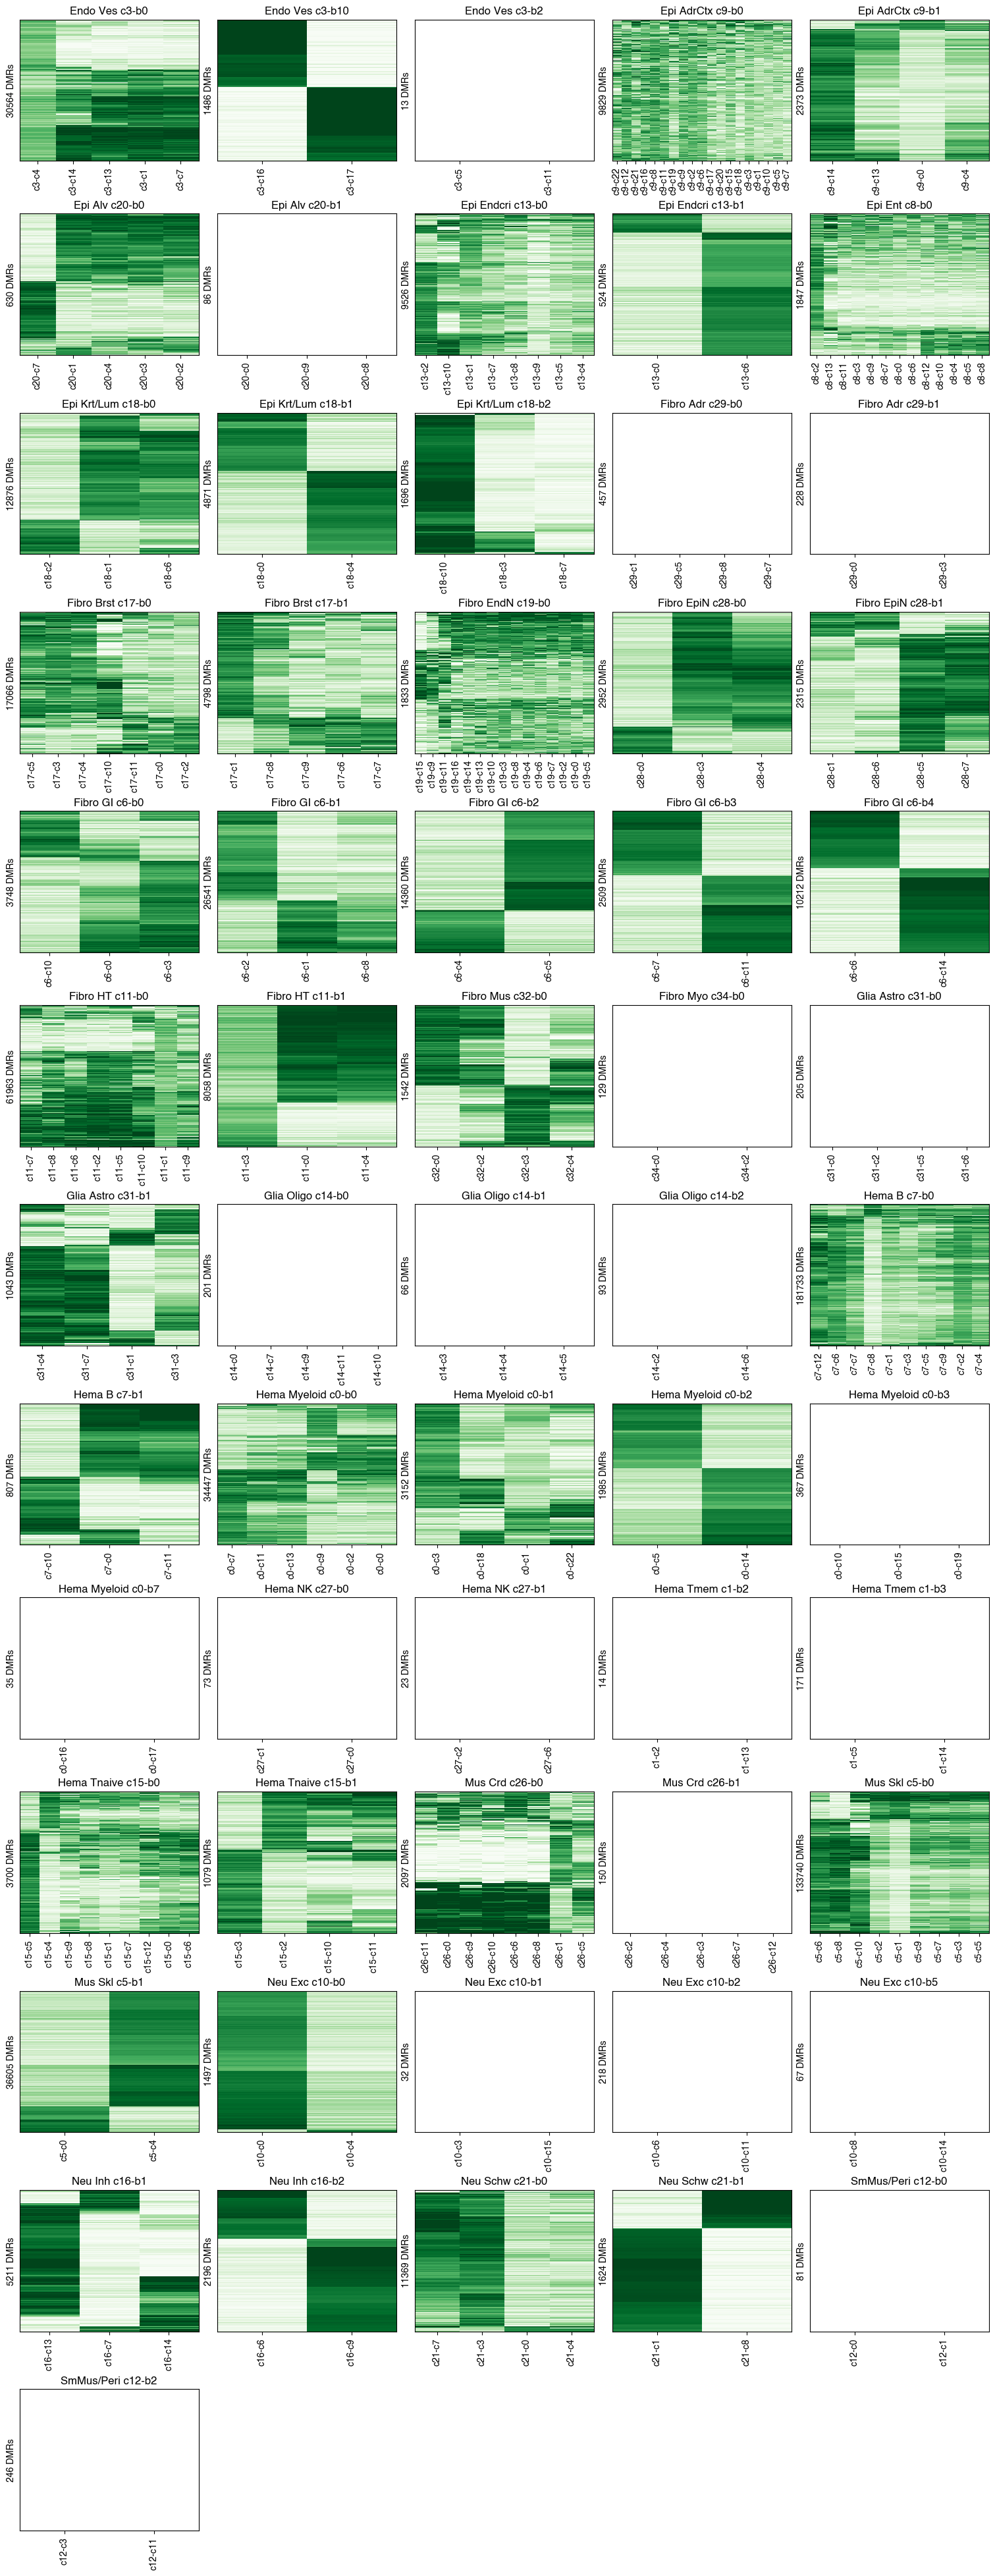

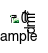

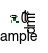

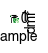

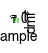

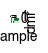

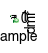

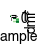

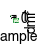

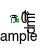

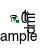

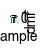

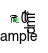

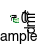

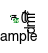

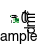

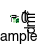

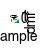

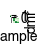

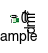

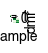

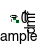

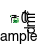

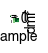

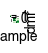

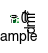

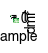

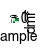

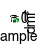

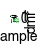

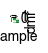

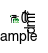

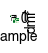

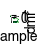

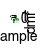

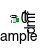

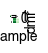

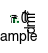

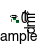

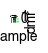

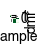

In [45]:
ncol = 5
nrow = (ngroup - 1) // ncol + 1

k = 0
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow), constrained_layout=True)
for l1 in dmr_group:
    for l2b in dmr_group[l1]:
        ax = axes.flatten()[k]
        k += 1
        if not os.path.exists(f'{indir}DMR/L2both-L2any/{l2b}_dmr'):
            continue
        dmr_ds = RegionDS.open(f'{indir}DMR/L2both-L2any/{l2b}_dmr', region_dim='dmr')
        dmr = dmr_ds[['dmr_chrom', 'dmr_start', 'dmr_end', 'dmr_ndms']].to_pandas()
        dmr[['dmr_start', 'dmr_end', 'dmr_ndms']] = dmr[['dmr_start', 'dmr_end', 'dmr_ndms']].astype(int)
        seldmr = (dmr['dmr_ndms']>1) & (dmr['dmr_chrom'].isin(chrom_sizes.index))
        dmr_ds = dmr_ds.sel({'dmr':dmr.index[seldmr]})
        data = dmr_ds['dmr_da_frac'].to_pandas().fillna(1).T

        ax.set_xticks(np.arange(data.shape[1]))
        ax.set_xlim([-0.5, data.shape[1]-0.5])
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks([])
        ax.set_ylabel(f'{data.shape[0]} DMRs')
        ax.set_title(f'{l1} {l2b}')

        np.random.seed(0)
        if data.shape[0]>5000:
            sel = np.random.choice(np.arange(data.shape[0]), 5000, False)
        elif data.shape[0]>500:
            sel = np.arange(data.shape[0])
        else:
            continue
        cg = sns.clustermap(data.iloc[sel], cmap='Greens_r', metric='cosine', figsize=(0.1,0.1))
        tmp = data.iloc[sel].iloc[cg.dendrogram_row.reordered_ind, cg.dendrogram_col.reordered_ind]
        ax.imshow(tmp, aspect='auto', cmap='Greens_r', vmin=0, vmax=1, interpolation='none', rasterized=True)
        ax.set_xticklabels(tmp.columns, rotation=90)

for ax in axes.flatten()[k:]:
    ax.axis('off')

fig.savefig('L2any_L2both/L2any_L2both_DMR.pdf', transparent=True)


In [30]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


1.9599639845400545 1.0364333894937898


c3-b0 14210 0 0
c3-b10 679 0 0
c3-b2 4661 0 0
c9-b0 27008 0 0
c9-b1 25131 0 0
c20-b0 33465 0 0
c20-b1 11978 0 0
c13-b0 31271 0 0
c13-b1 14795 0 0
c8-b0 74704 860 860
c18-b0 36359 0 0
c18-b1 27302 0 0
c18-b2 13634 0 0
c29-b0 7849 0 0
c29-b1 6724 0 0
c17-b0 26918 9 9
c17-b1 28536 0 0
c19-b0 57590 0 0
c28-b0 26215 0 0
c28-b1 20822 0 0
c6-b0 30348 0 0
c6-b1 29156 0 0
c6-b2 14042 0 0
c6-b3 10988 0 0
c6-b4 8039 25 25
c11-b0 27295 9 9
c11-b1 13249 0 0
c32-b0 7065 0 0
c34-b0 10507 0 0
c31-b0 3958 0 0
c31-b1 4741 0 0
c14-b0 28111 0 0
c14-b1 27364 0 0
c14-b2 26849 0 0
c7-b0 25497 13614 13537
c7-b1 14372 10 10
c0-b0 28737 5697 5697
c0-b1 16510 3 3
c0-b2 23043 0 0
c0-b3 36727 0 0
c0-b7 8468 0 0
c27-b0 6220 0 0
c27-b1 3767 0 0
c1-b2 6896 0 0
c1-b3 4909 0 0
c15-b0 20523 0 0
c15-b1 12032 0 0
c26-b0 16128 0 0
c26-b1 19265 0 0
c5-b0 9842 1113 1113
c5-b1 2040 0 0
c10-b0 22409 0 0
c10-b1 23048 0 0
c10-b2 29742 0 0
c10-b5 19704 0 0
c16-b1 7464 0 0
c16-b2 7439 0 0
c21-b0 35218 740 740
c21-b1 7009 11 11
c12

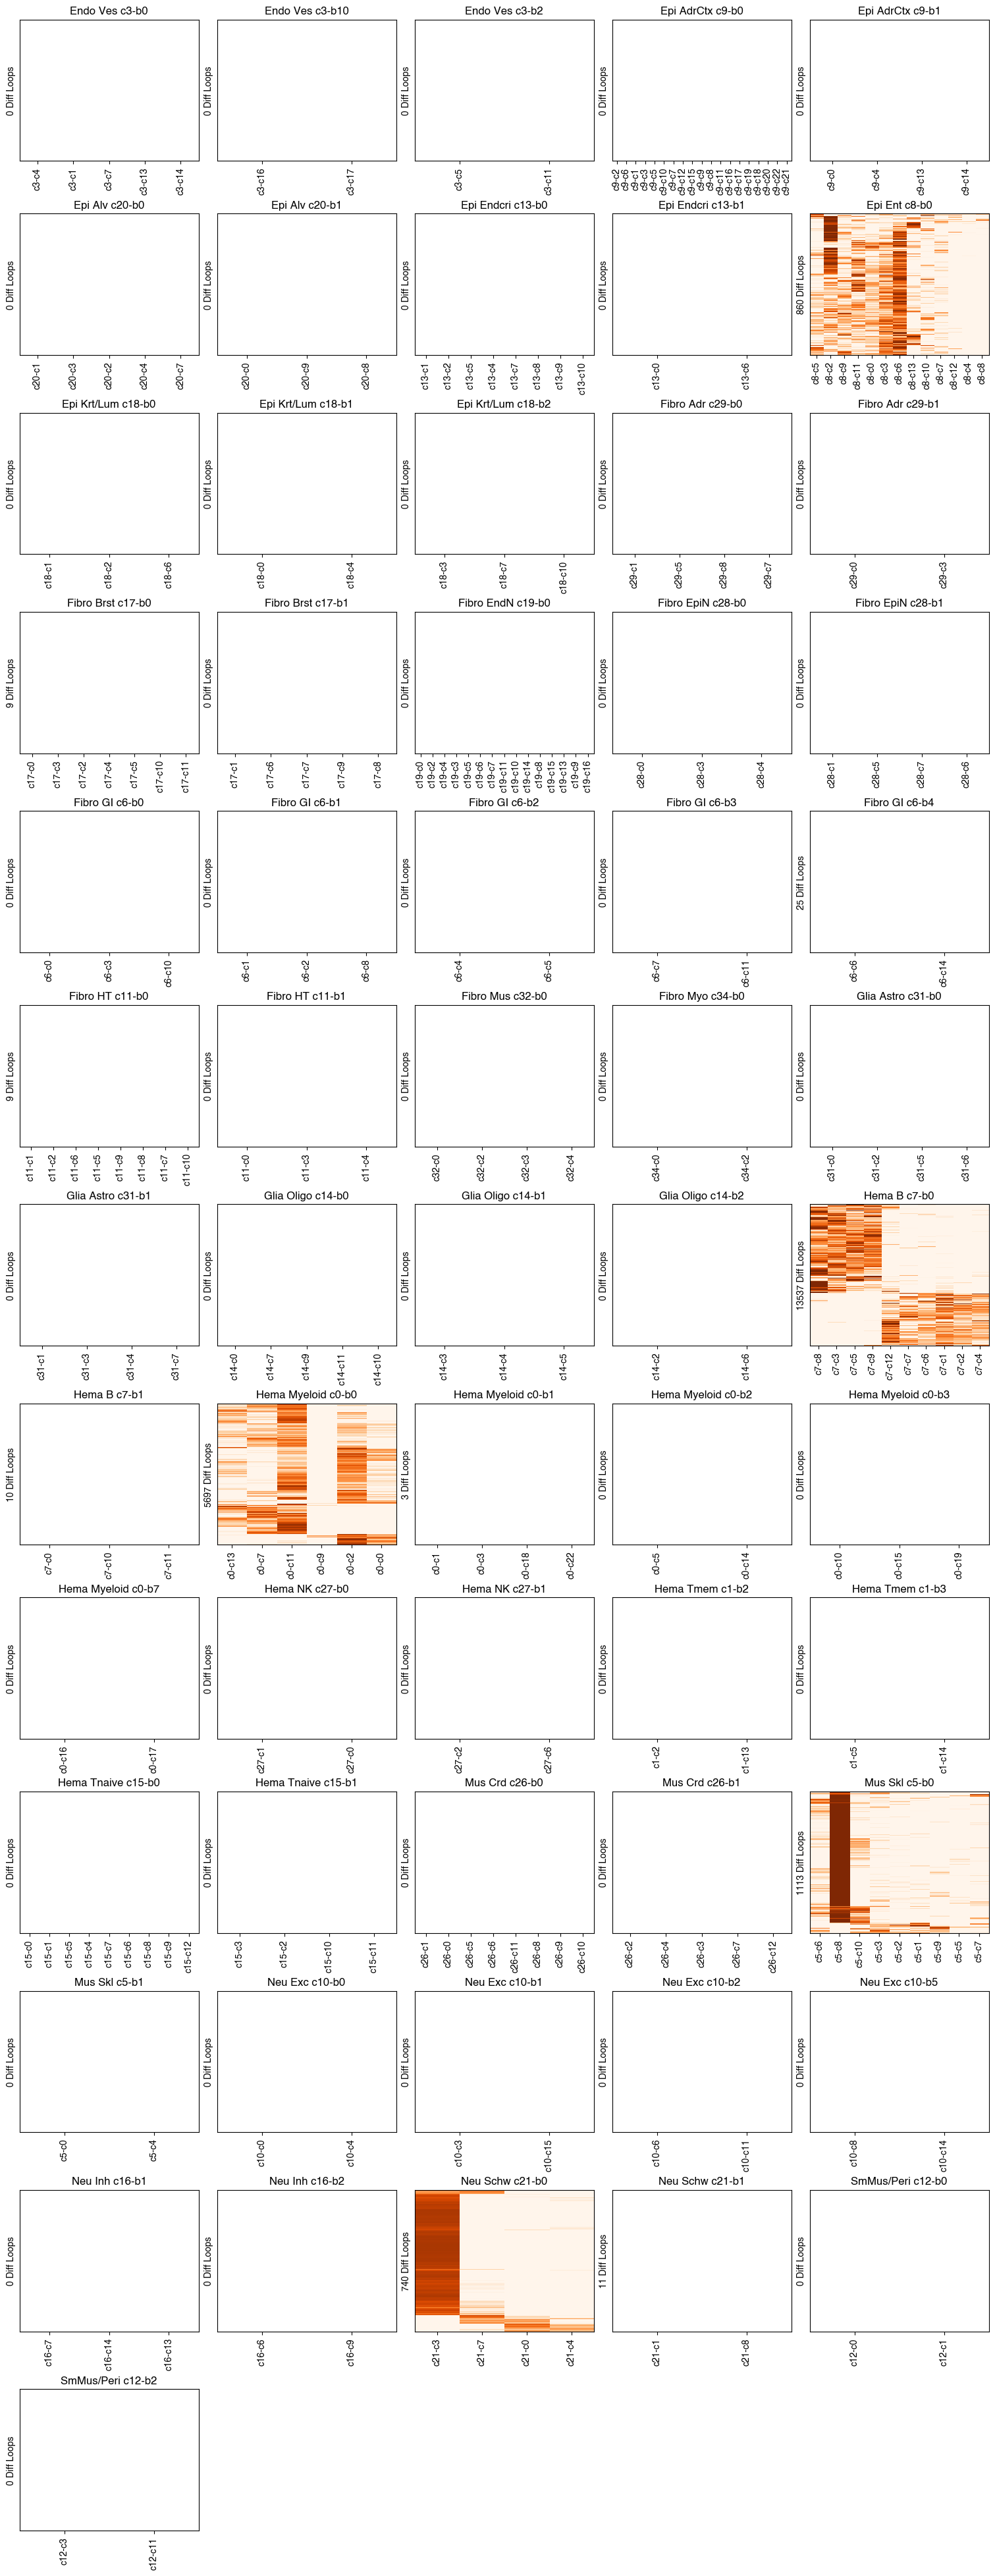

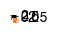

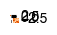

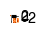

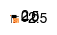

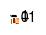

In [39]:
ncol = 5
nrow = (ngroup - 1) // ncol + 1
fdrthres = 1e-3
k = 0
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow), constrained_layout=True)
for l1 in dmr_group:
    for l2b in dmr_group[l1]:
        ax = axes.flatten()[k]
        k += 1
        tmpdir = f'{indir}analysis/L2any_L2both_diffloop/{l2b}/'
        loopq = pd.read_hdf(f'{tmpdir}loop_Q.hdf', key='data')
        loopall = pd.read_hdf(f'{tmpdir}merged_loop.hdf', key='data')
        
        statfilter = (zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2)
        fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
        selloop = statfilter & fdrfilter
        print(l2b, statfilter.sum(), fdrfilter.sum(), selloop.sum())
        data = loopq.loc[selloop]
        
        ax.set_xticks(np.arange(data.shape[1]))
        ax.set_xlim([-0.5, data.shape[1]-0.5])
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks([])
        ax.set_ylabel(f'{data.shape[0]} Diff Loops')
        ax.set_title(f'{l1} {l2b}')
        
        np.random.seed(0)
        if data.shape[0]>5000:
            sel = np.random.choice(np.arange(data.shape[0]), 5000, False)
        elif data.shape[0]>500:
            sel = np.arange(data.shape[0])
        else:
            continue
        cg = sns.clustermap(zscore(data.iloc[sel], axis=1), cmap='Oranges', metric='cosine', figsize=(0.1,0.1))
        tmp = data.iloc[sel].iloc[cg.dendrogram_row.reordered_ind, cg.dendrogram_col.reordered_ind]
        ax.imshow(zscore(tmp, axis=1), aspect='auto', cmap='Oranges', vmin=0, vmax=2, interpolation='none', rasterized=True)
        ax.set_xticklabels(tmp.columns, rotation=90)
    
for ax in axes.flatten()[k:]:
    ax.axis('off')


c3-b0 14210 478 478
c3-b10 679 0 0
c3-b2 4661 1181 1181
c9-b0 27008 1598 1598
c9-b1 25131 0 0
c20-b0 33465 317 317
c20-b1 11978 129 129
c13-b0 31271 1 1
c13-b1 14795 0 0
c8-b0 74704 35246 35246
c18-b0 36359 5 5
c18-b1 27302 0 0
c18-b2 13634 308 308
c29-b0 7849 726 726
c29-b1 6724 0 0
c17-b0 26918 733 733
c17-b1 28536 533 533
c19-b0 57590 199 199
c28-b0 26215 8 8
c28-b1 20822 23 23
c6-b0 30348 16 16
c6-b1 29156 197 197
c6-b2 14042 382 382
c6-b3 10988 0 0
c6-b4 8039 7029 6485
c11-b0 27295 1724 1724
c11-b1 13249 4 4
c32-b0 7065 14 14
c34-b0 10507 0 0
c31-b0 3958 9 9
c31-b1 4741 29 29
c14-b0 28111 62 62
c14-b1 27364 0 0
c14-b2 26849 0 0
c7-b0 25497 81518 25495
c7-b1 14372 1209 1209
c0-b0 28737 111021 28737
c0-b1 16510 1028 1028
c0-b2 23043 0 0
c0-b3 36727 37 37
c0-b7 8468 0 0
c27-b0 6220 0 0
c27-b1 3767 31 31
c1-b2 6896 164 164
c1-b3 4909 162 162
c15-b0 20523 0 0
c15-b1 12032 91 91
c26-b0 16128 36 36
c26-b1 19265 1350 1350
c5-b0 9842 19105 9842
c5-b1 2040 2 2
c10-b0 22409 0 0
c10-b1 23048 

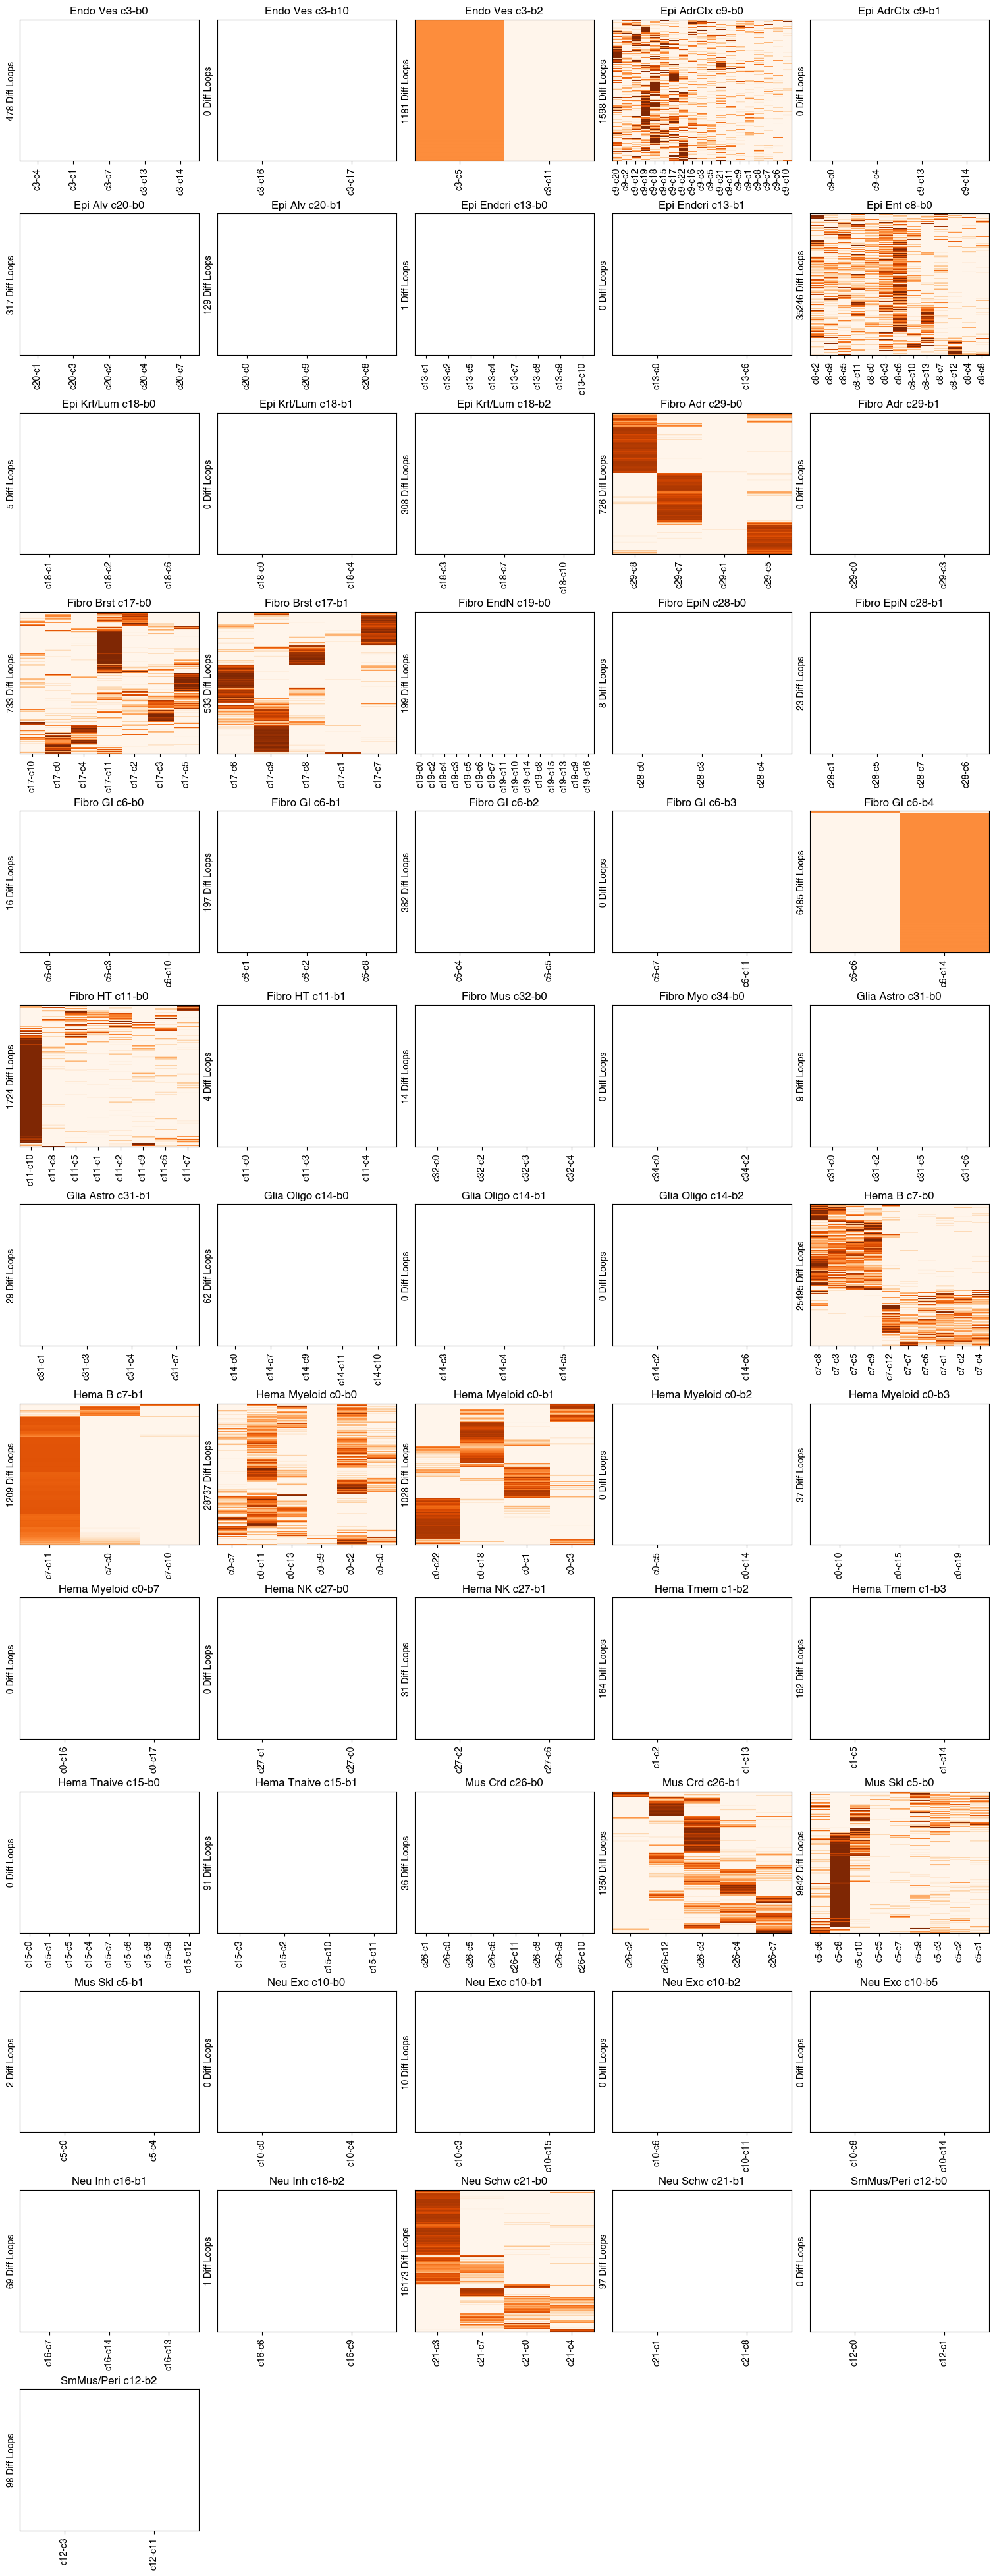

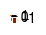

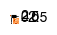

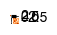

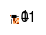

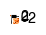

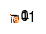

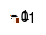

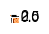

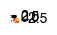

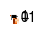

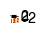

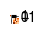

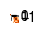

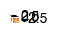

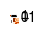

In [44]:
ncol = 5
nrow = (ngroup - 1) // ncol + 1
fdrthres = 1e-1
k = 0
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow), constrained_layout=True)
for l1 in dmr_group:
    for l2b in dmr_group[l1]:
        ax = axes.flatten()[k]
        k += 1
        tmpdir = f'{indir}analysis/L2any_L2both_diffloop/{l2b}/'
        loopq = pd.read_hdf(f'{tmpdir}loop_Q.hdf', key='data')
        loopall = pd.read_hdf(f'{tmpdir}merged_loop.hdf', key='data')
        
        statfilter = (zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2)
        fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
        selloop = statfilter & fdrfilter
        print(l2b, statfilter.sum(), fdrfilter.sum(), selloop.sum())
        data = loopq.loc[selloop]
        
        ax.set_xticks(np.arange(data.shape[1]))
        ax.set_xlim([-0.5, data.shape[1]-0.5])
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks([])
        ax.set_ylabel(f'{data.shape[0]} Diff Loops')
        ax.set_title(f'{l1} {l2b}')

        np.random.seed(0)
        if data.shape[0]>5000:
            sel = np.random.choice(np.arange(data.shape[0]), 5000, False)
        elif data.shape[0]>500:
            sel = np.arange(data.shape[0])
        else:
            continue
        cg = sns.clustermap(zscore(data.iloc[sel], axis=1), cmap='Oranges', metric='cosine', figsize=(0.1,0.1))
        tmp = data.iloc[sel].iloc[cg.dendrogram_row.reordered_ind, cg.dendrogram_col.reordered_ind]
        ax.imshow(zscore(tmp, axis=1), aspect='auto', cmap='Oranges', vmin=0, vmax=2, interpolation='none', rasterized=True)
        ax.set_xticklabels(tmp.columns, rotation=90)
    
for ax in axes.flatten()[k:]:
    ax.axis('off')

fig.savefig('L2any_L2both/L2any_L2both_diffloop.pdf', transparent=True)


In [9]:
L1annot = meta[['L1','L1_annot']].drop_duplicates().set_index('L1')['L1_annot']


In [ ]:
cat <(for i in `seq 0 34`; do echo c${i} $(bedtools intersect -wa -a L1-L2both/c${i}_dmr/dmr.bed -b L1-L2any/c${i}_dmr/dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(cat L1-L2both/c${i}_dmr/dmr.bed | wc -l); done) > L2both_L2anyratio.txt
cat <(for i in `seq 0 34`; do echo c${i} $(bedtools intersect -wa -b L1-L2both/c${i}_dmr/dmr.bed -a L1-L2any/c${i}_dmr/dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(cat L1-L2any/c${i}_dmr/dmr.bed | wc -l); done) > L2any_L2bothratio.txt



In [57]:
tmp = pd.read_csv(f'{indir}DMR/L2any_L2bothratio.txt', index_col=0, header=None, sep=' ')
tmp.index = tmp.index.map(L1annot)
tmp['ratio'] = tmp[1]/tmp[2]
tmp

,1,2,ratio
0,,,
Hema Myeloid,158785,211440,0.750970
Hema Tmem,114801,120391,0.953568
Epi TPB,173307,194222,0.892314
Endo Ves,587827,622036,0.945005
Epi Gas,0,42741,0.000000
Mus Skl,10320,175114,0.058933
Fibro GI,268714,346726,0.775004
Hema B,1142495,1524814,0.749268
Epi Ent,84008,112936,0.743855


In [58]:
tmp = pd.read_csv(f'{indir}DMR/L2both_L2anyratio.txt', index_col=0, header=None, sep=' ')
tmp.index = tmp.index.map(L1annot)
tmp['ratio'] = tmp[1]/tmp[2]
tmp

,1,2,ratio
0,,,
Hema Myeloid,154487,172376,0.896221
Hema Tmem,110466,1892303,0.058376
Epi TPB,168392,2156883,0.078072
Endo Ves,559197,1258225,0.444433
Epi Gas,0,0,NaN
Mus Skl,9698,9888,0.980785
Fibro GI,278186,305631,0.910202
Hema B,1167871,1185691,0.984971
Epi Ent,77965,85581,0.911008


In [56]:
dmr_ds = RegionDS.open(f'{indir}DMR/L1-L2both/c2_dmr', region_dim='dmr')
dmr_ds

<xarray.RegionDS> Size: 3GB
Dimensions:      (count_type: 2, dmr: 5008469, sample: 36)
Coordinates:
  * count_type   (count_type) <U3 24B 'mc' 'cov'
  * dmr          (dmr) <U12 240MB 'chr1-0' 'chr1-1' ... 'chrY-41945'
    dmr_chrom    (dmr) <U5 100MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_end      (dmr) float64 40MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_length   (dmr) float64 40MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_ndms     (dmr) int64 40MB dask.array<chunksize=(4096,), meta=np.ndarray>
    dmr_start    (dmr) float64 40MB dask.array<chunksize=(4096,), meta=np.ndarray>
  * sample       (sample) <U6 864B 'c23-b4' 'c27-b2' ... 'c23-b1' 'c27-b5'
Data variables:
    dmr_da       (sample, dmr, count_type) uint32 1GB dask.array<chunksize=(7, 4096, 1), meta=np.ndarray>
    dmr_da_frac  (sample, dmr) float32 721MB dask.array<chunksize=(7, 4096), meta=np.ndarray>
    dmr_state    (sample, dmr) int8 180MB dask.array<chunksize=(7, 4096), meta=np.ndarray>
Attributes:
    region_dim:          dmr
    region_ds_location:  /large_storage/zhoulab/zhoujt/project/ENTEx/DMR/L1-L...
    chrom_size_path:     /large_storage/zhoulab/zhoujt/project/ENTEx/DMR/L1-L...

In [11]:
result = []
for l1,l1name in meta[['L1','L1_annot']].drop_duplicates().values:
    l1annot = l1name.replace('/','_').replace(' ','-')
    corr_path_l2both = f'{indir}analysis/L2any_L2both/dmr_loop_corr/L2both/{l1}_{l1annot}_corr.npz'
    corr_path_l2any = f'{indir}analysis/L2any_L2both/dmr_loop_corr/L2any/{l1}_{l1annot}_corr.npz'
    if not os.path.exists(corr_path_l2both):
        continue
    corr_l2both = np.load(corr_path_l2both)
    corr_l2any = np.load(corr_path_l2any)
    result.append([l1, l1annot, 
                   np.mean(corr_l2both['corr']), np.mean(corr_l2any['corr']), 
                   np.mean(corr_l2both['corr_colnorm']), np.mean(corr_l2any['corr_colnorm'])])

result = pd.DataFrame(result, columns=['L1', 'L1annot', 
                                       'corr_L2both', 'corr_L2any', 
                                       'corr_colnorm_L2both', 'corr_colnorm_L2any']).set_index('L1')


In [4]:
corr_l2any_dmr = []
corr_l2any_bin = []

for l1,l1name in meta[['L1','L1_annot']].drop_duplicates().values:
    l1annot = l1name.replace('/','_').replace(' ','-')
    corr_path_l2any = f'{indir}analysis/L2any_L2both/dmr_loop_corr/L2any/{l1}_{l1annot}_corr.npz'    
    corr_l2any_tmp = np.load(corr_path_l2any)
    corr_l2any_tmp = pd.DataFrame(corr_l2any_tmp['corr'][:, None], columns=['corr'])
    corr_l2any_tmp['L1'] = l1
    corr_l2any_tmp['L1annot'] = l1name
    corr_l2any_dmr.append(corr_l2any_tmp)
    corr_path_l2any = f'{indir}analysis/L2any_L2both/dmr_loop_corr/L2any/{l1}_{l1annot}_10kmcg_corr.npz'    
    corr_l2any_tmp = np.load(corr_path_l2any)
    corr_l2any_tmp = pd.DataFrame(corr_l2any_tmp['corr'][:, None], columns=['corr'])
    corr_l2any_tmp['L1'] = l1
    corr_l2any_tmp['L1annot'] = l1name
    corr_l2any_bin.append(corr_l2any_tmp)

corr_l2any_dmr = pd.concat(corr_l2any_dmr, axis=0)
corr_l2any_bin = pd.concat(corr_l2any_bin, axis=0)



In [18]:
from sklearn.metrics import adjusted_rand_score as ARI

labelmc, label3c, score = [], [], {}
for l1,l1name in meta[['L1','L1_annot']].drop_duplicates().values:
    l1name = l1name.replace(' ','-').replace('/','_')
    adata = anndata.read_h5ad(f'{indir}clustering/merged/L2/{l1name}/5kCG100k3C_embed.h5ad')
    tmp1 = np.load(f'{indir}clustering/merged/L2_hiconly/{l1name}/mergemcg_rocpr.npy', allow_pickle=True)
    labelmc.append(pd.Series(tmp1, index=adata.obs.index))
    tmp2 = np.load(f'{indir}clustering/merged/L2_hiconly/{l1name}/mergehic_rocpr.npy', allow_pickle=True)
    label3c.append(pd.Series(tmp2, index=adata.obs.index))
    score[l1] = ARI(tmp1, tmp2)
    
labelmc = pd.concat(labelmc)
label3c = pd.concat(label3c)
score = pd.Series(score)


In [21]:
result['ARI'] = score.copy()


In [12]:
corr_l2any.groupby('L1')['corr'].median().sort_values().index

Index(['c34', 'c16', 'c13', 'c14', 'c10', 'c26', 'c30', 'c5', 'c27', 'c4',
       'c20', 'c23', 'c29', 'c28', 'c21', 'c6', 'c31', 'c0', 'c19', 'c11',
       'c12', 'c32', 'c17', 'c24', 'c18', 'c15', 'c8', 'c9', 'c2', 'c7', 'c22',
       'c1', 'c25', 'c3', 'c33'],
      dtype='object', name='L1')

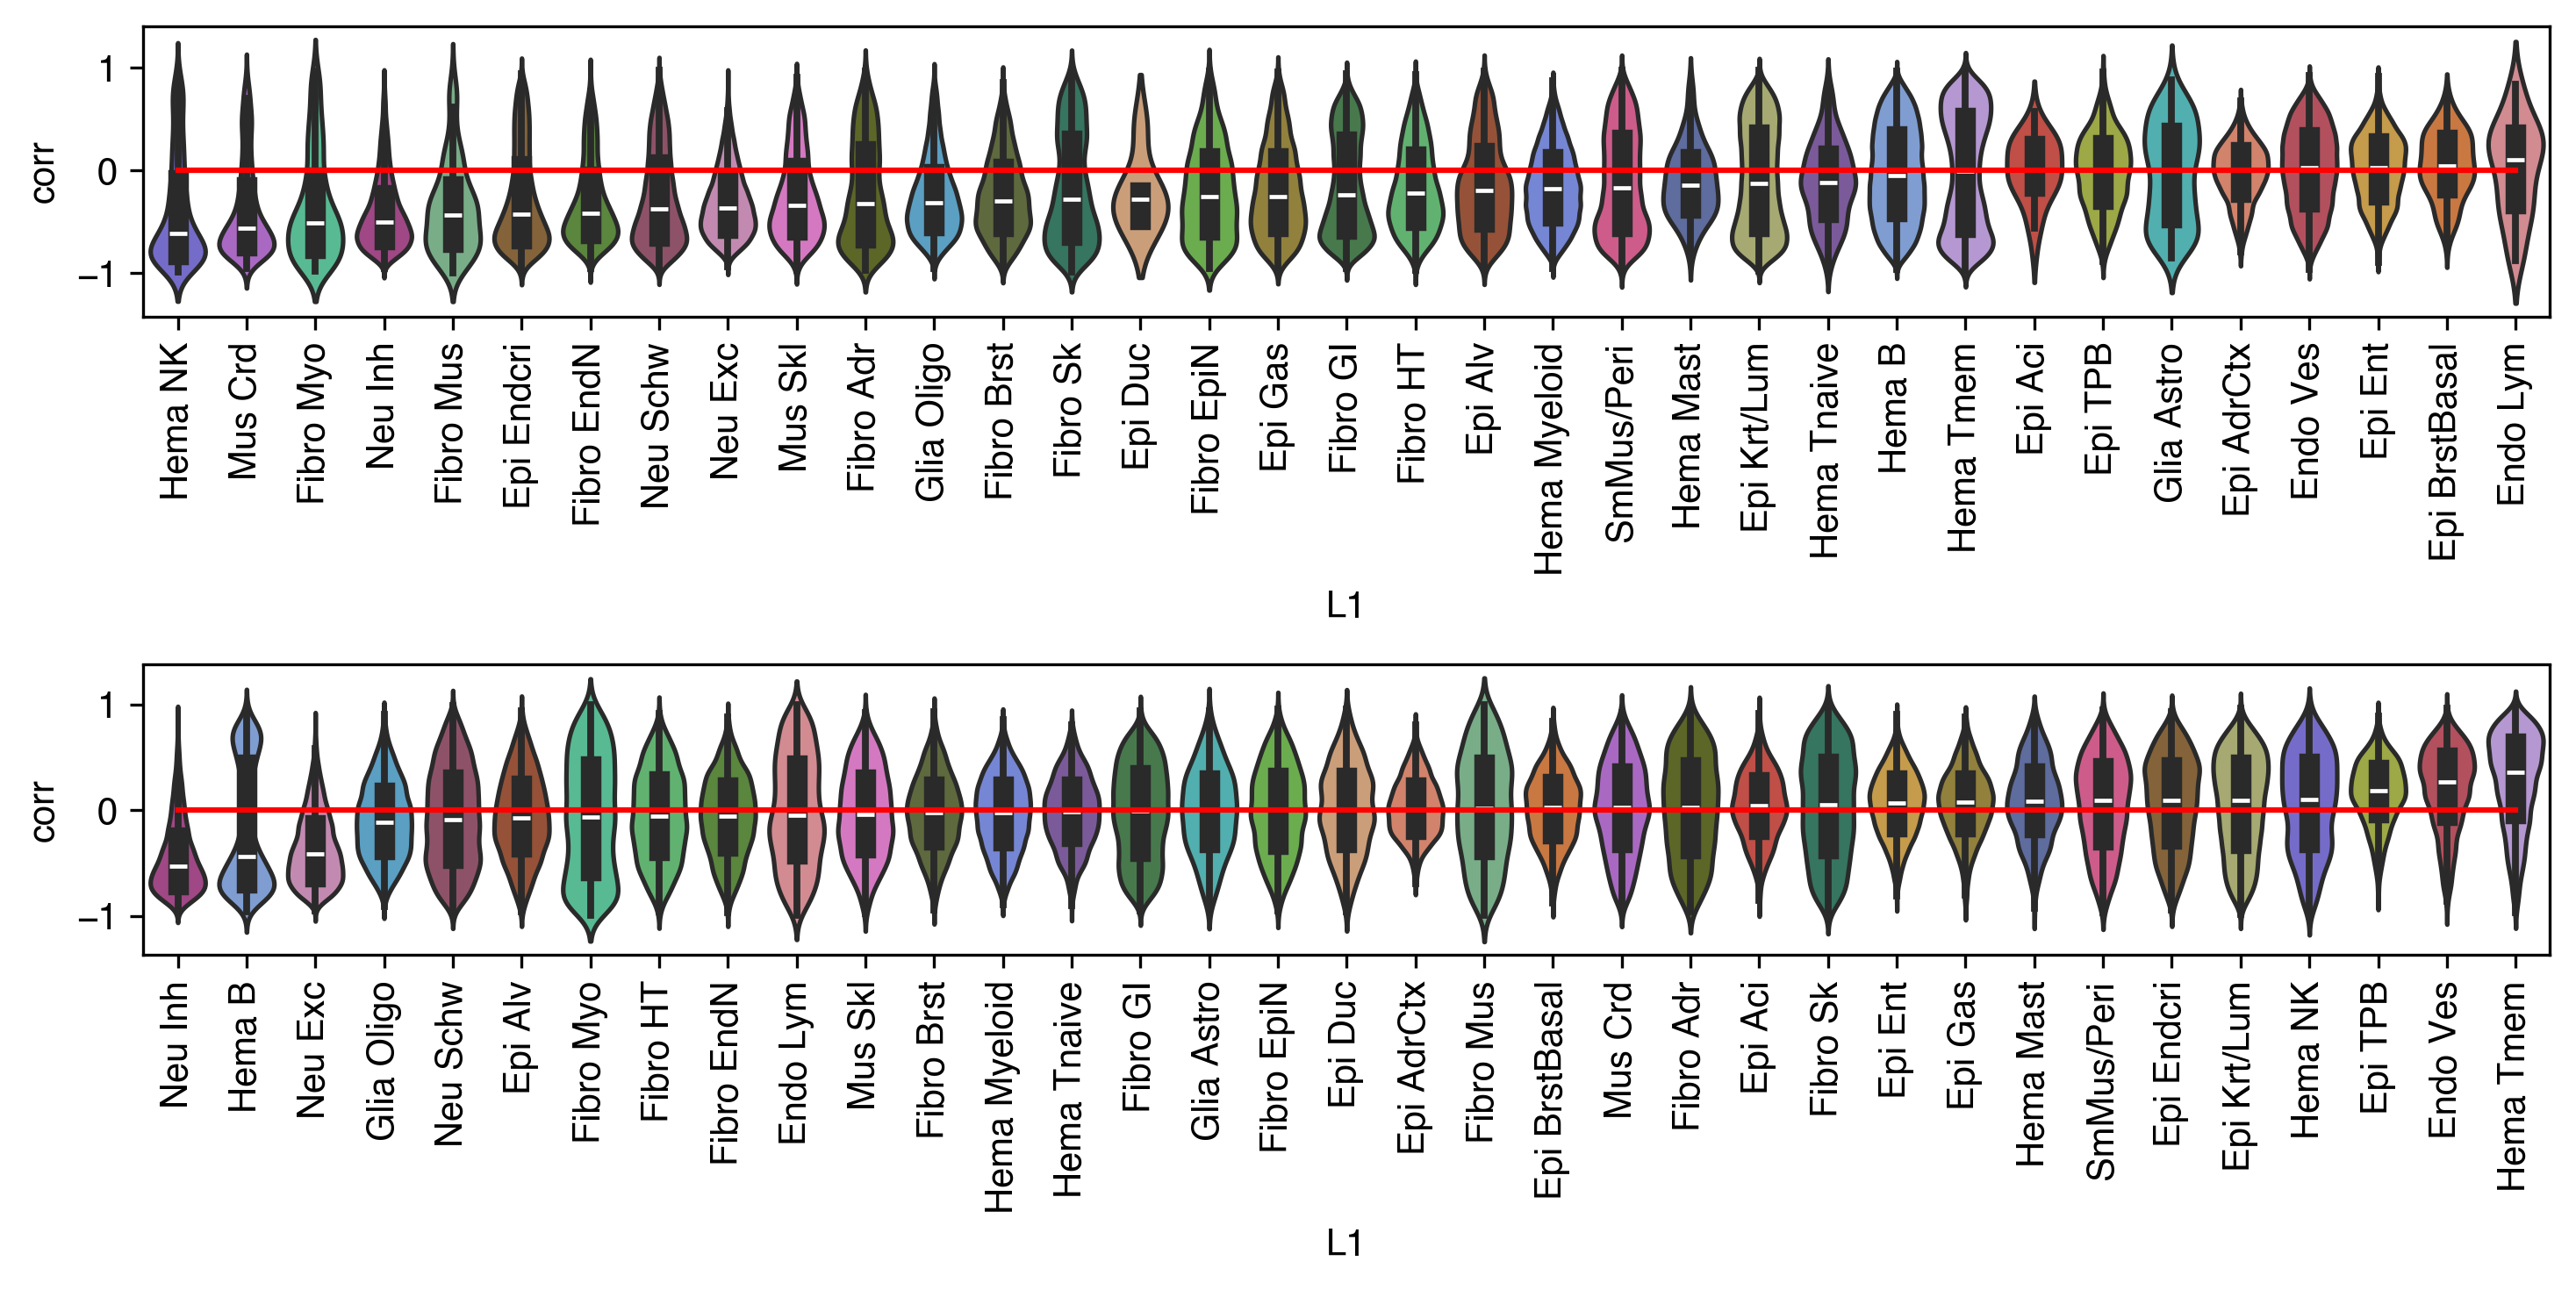

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(10,5), dpi=300)

ax = axes[0]
legorder = corr_l2any_dmr.groupby('L1')['corr'].median().sort_values().index
sns.violinplot(corr_l2any_dmr, x='L1', y='corr', palette=colors.to_dict(), ax=ax, order=legorder)
ax.set_xticklabels(L1annot.loc[legorder], rotation=90)
ax.plot([0,len(legorder)-1], [0, 0], 'r')
ax.set_xlim([-0.5, len(legorder)-0.5])

ax = axes[1]
legorder = corr_l2any_bin.groupby('L1')['corr'].median().sort_values().index
sns.violinplot(corr_l2any_bin, x='L1', y='corr', palette=colors.to_dict(), ax=ax, order=legorder)
ax.set_xticklabels(L1annot.loc[legorder], rotation=90)
ax.plot([0,len(legorder)-1], [0, 0], 'r')
ax.set_xlim([-0.5, len(legorder)-0.5])

plt.tight_layout()


In [23]:
colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color']
colors

L1
c33    #dd7f87
c3     #c43f52
c22    #d33d33
c9     #e37a5b
c20    #a44b29
c25    #e0742b
c30    #d99d6c
c13    #91652d
c8     #d9a138
c4     #9f892f
c18    #aeb268
c2     #a9b836
c29    #63711c
c17    #627037
c19    #579232
c28    #65bc3f
c6     #3f8146
c11    #53c067
c32    #6fb685
c34    #46cb97
c23    #2b7f63
c31    #41bfbf
c14    #4aa5d4
c7     #7199df
c24    #5366a9
c0     #657ce4
c27    #695dd8
c1     #b58edb
c15    #7c4fa5
c26    #af5ad1
c5     #e36aca
c10    #cc81b4
c16    #ad398b
c21    #984866
c12    #e04986
Name: color, dtype: object

In [42]:
real_d = {}
for f in glob('L2any_L2both/dmr_loop_enrich/L2any/c*_score_bylevel.npz'):
    cluster = f.split('/')[-1].replace('_score_bylevel.npz','')
    # name = L1annot[cluster]
    overlap = np.load(f)
    real_d[cluster] =list(overlap['score']) 


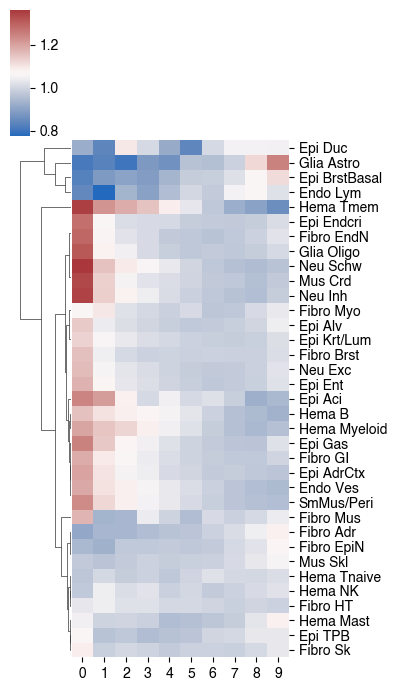

In [35]:
sns.clustermap(score, cmap='vlag', metric='cosine', col_cluster=False, figsize=(4,7), yticklabels=1)


[Text(0, 0, 'Glia Astro'),
 Text(0, 1, 'Epi BrstBasal'),
 Text(0, 2, 'Endo Lym'),
 Text(0, 3, 'Fibro Adr'),
 Text(0, 4, 'Epi Duc'),
 Text(0, 5, 'Fibro EpiN'),
 Text(0, 6, 'Hema Tnaive'),
 Text(0, 7, 'Hema NK'),
 Text(0, 8, 'Mus Skl'),
 Text(0, 9, 'Fibro HT'),
 Text(0, 10, 'Hema Mast'),
 Text(0, 11, 'Fibro Myo'),
 Text(0, 12, 'Epi TPB'),
 Text(0, 13, 'Fibro Sk'),
 Text(0, 14, 'Epi Krt/Lum'),
 Text(0, 15, 'Epi Alv'),
 Text(0, 16, 'Hema B'),
 Text(0, 17, 'Fibro Brst'),
 Text(0, 18, 'Neu Exc'),
 Text(0, 19, 'Fibro Mus'),
 Text(0, 20, 'Epi Ent'),
 Text(0, 21, 'Fibro GI'),
 Text(0, 22, 'Endo Ves'),
 Text(0, 23, 'Hema Myeloid'),
 Text(0, 24, 'Epi AdrCtx'),
 Text(0, 25, 'SmMus/Peri'),
 Text(0, 26, 'Epi Aci'),
 Text(0, 27, 'Epi Gas'),
 Text(0, 28, 'Epi Endcri'),
 Text(0, 29, 'Fibro EndN'),
 Text(0, 30, 'Glia Oligo'),
 Text(0, 31, 'Mus Crd'),
 Text(0, 32, 'Neu Inh'),
 Text(0, 33, 'Hema Tmem'),
 Text(0, 34, 'Neu Schw')]

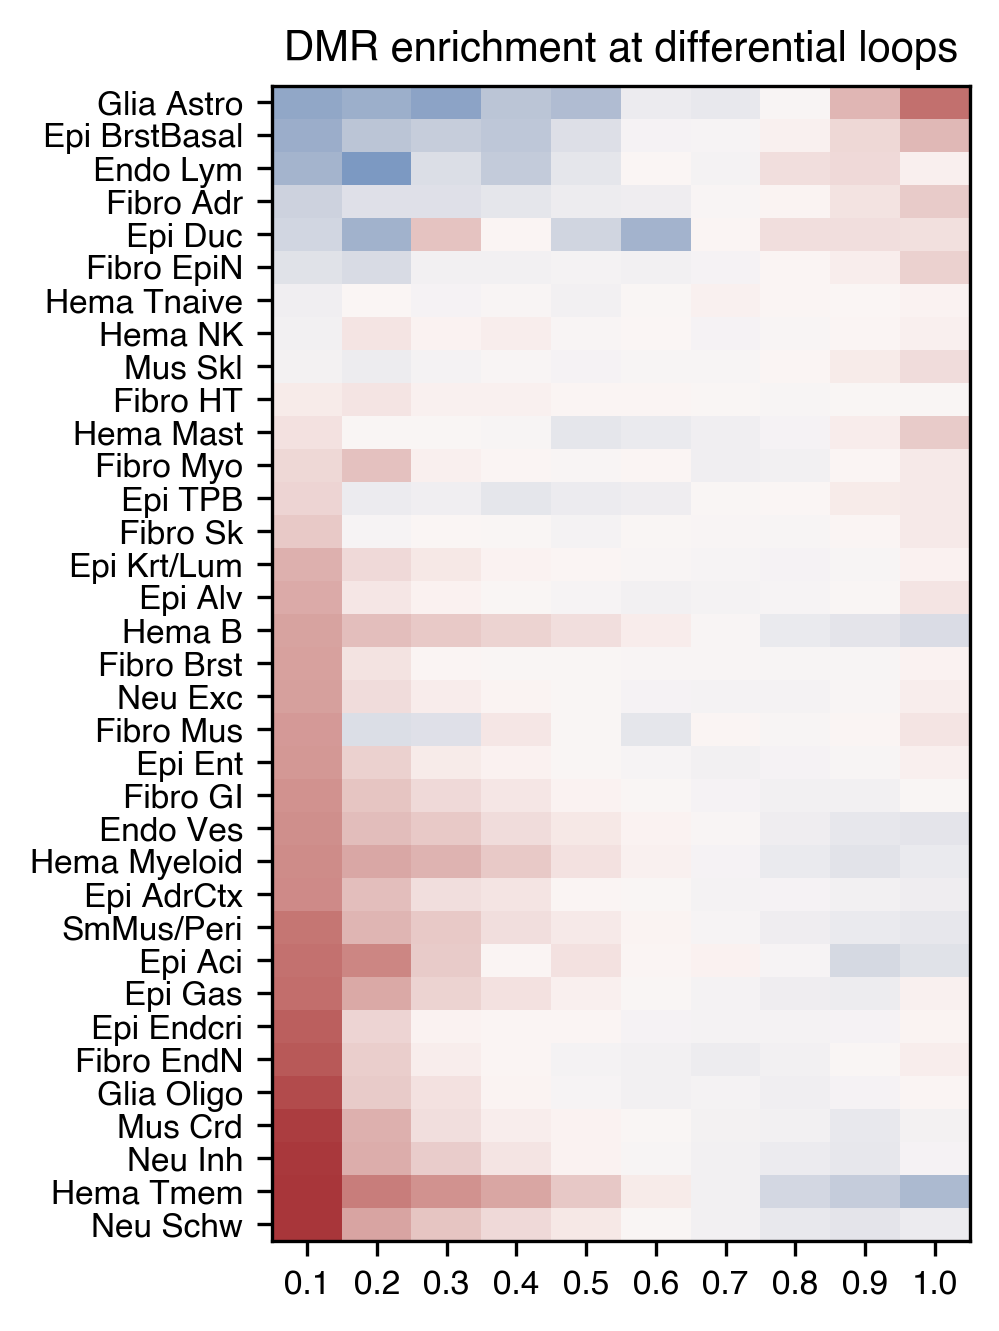

In [43]:
from scipy.stats import pearsonr

score = pd.DataFrame.from_dict(real_d, orient='index').fillna(0)
# corr = np.array([pearsonr(np.arange(10), xx)[0] for xx in score.values])
corr = score.values[:,0]
# sel = score.mean(axis=1).sort_values().index[::-1]
score = score.iloc[np.argsort(corr)]

fig, ax = plt.subplots(figsize=(3,5), dpi=300)
ax.imshow(score, cmap='vlag',  aspect='auto',vmin=0.65,vmax=1.35, interpolation='none',rasterized=True)
ax.set_title('DMR enrichment at differential loops', fontsize=10)
ax.set_xticks(np.arange(score.shape[1]))
ax.set_xticklabels([(i+1)/10 for i in range(10)],fontsize=8)
ax.set_yticks(np.arange(score.shape[0]))
ax.set_yticklabels(score.index.map(L1annot),fontsize=8)


In [44]:
enrich = pd.Series({xx: pearsonr(np.arange(10), yy)[0] for xx,yy in zip(score.index,score.values)})
enrich.sort_values()

c7    -0.993138
c1    -0.990156
c0    -0.975333
c3    -0.965429
c12   -0.928158
c11   -0.916190
c22   -0.901089
c9    -0.886686
c21   -0.864421
c6    -0.863111
c4    -0.829712
c16   -0.822199
c26   -0.797493
c18   -0.758658
c8    -0.715467
c14   -0.691600
c10   -0.673274
c13   -0.663296
c19   -0.636614
c17   -0.624529
c34   -0.564446
c20   -0.515060
c23   -0.246876
c32   -0.159989
c27   -0.035972
c24    0.212324
c2     0.218511
c30    0.462152
c15    0.656034
c5     0.869496
c33    0.893017
c28    0.898566
c31    0.920245
c29    0.955956
c25    0.979272
dtype: float64

In [62]:
corr = corr_l2any_dmr.groupby('L1')['corr'].mean()
corr.sort_values()

L1
c16   -0.416438
c27   -0.398281
c26   -0.388535
c32   -0.368260
c34   -0.354351
c10   -0.312019
c19   -0.301209
c13   -0.281310
c21   -0.267308
c14   -0.253791
c5    -0.252497
c17   -0.246854
c30   -0.232405
c29   -0.218606
c28   -0.206338
c4    -0.191406
c23   -0.173729
c11   -0.164100
c0    -0.157883
c6    -0.146950
c20   -0.145920
c12   -0.114431
c15   -0.111727
c24   -0.111027
c18   -0.090108
c31   -0.033925
c7    -0.033339
c9    -0.024012
c2    -0.016587
c1    -0.012514
c22    0.004826
c3     0.009233
c8     0.009464
c33    0.023580
c25    0.046112
Name: corr, dtype: float64

In [63]:
result = pd.concat([enrich, corr], axis=1)
result.columns = ['DMR diffloop enrich', 'DMR diffloop corr']
result['L1annot'] = result.index.map(L1annot)

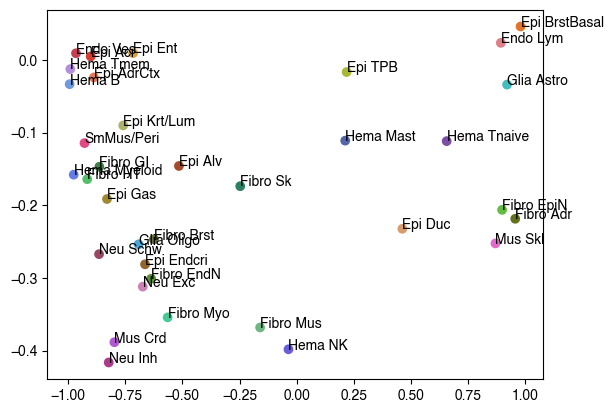

In [64]:
xl, yl = 'DMR diffloop enrich', 'DMR diffloop corr'
fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    

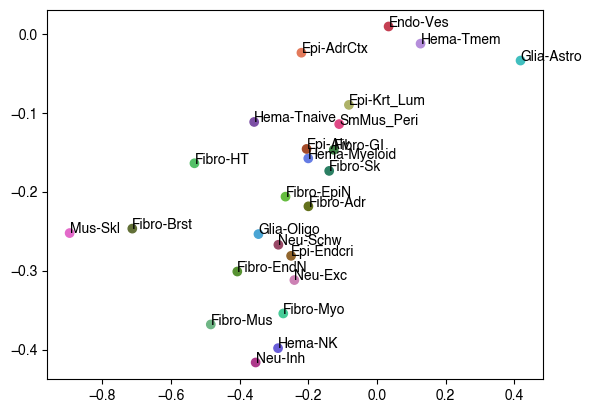

In [83]:
xl, yl = 'corr_L2both', 'corr_L2any'
fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    

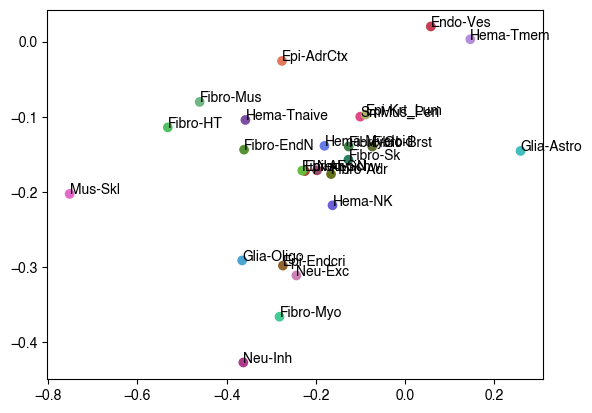

In [82]:
xl, yl = 'corr_colnorm_L2both', 'corr_colnorm_L2any'
fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    

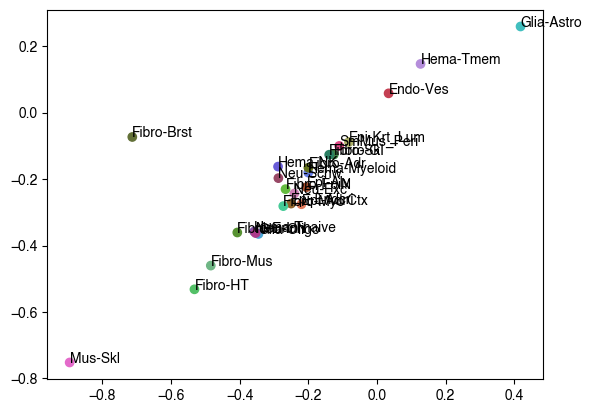

In [87]:
xl, yl = 'corr_L2both', 'corr_colnorm_L2both'

fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    

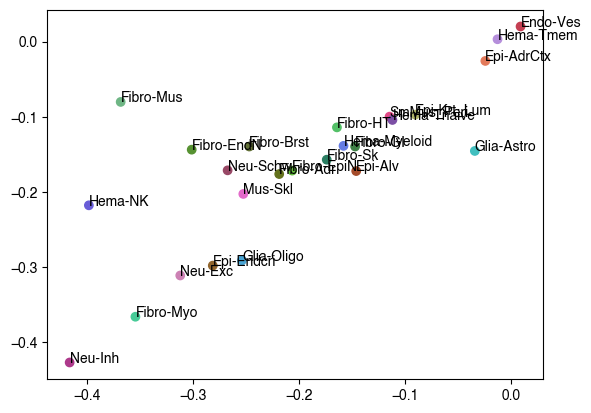

In [86]:
xl, yl = 'corr_L2any', 'corr_colnorm_L2any', 

fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    

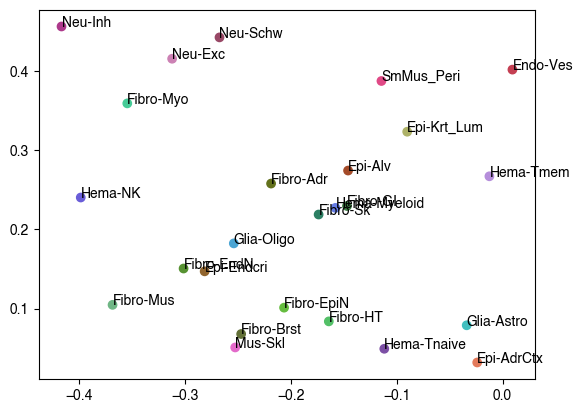

In [24]:
xl, yl = 'corr_L2any', 'ARI', 

fig, ax = plt.subplots()
ax.scatter(result[xl], result[yl], c=result.index.map(colors))
for xx,yy,l1 in result[[xl, yl, 'L1annot']].values:
    ax.text(xx, yy, l1)
    